# Depth Anything 3
Video → Depth GIF + 3D Point Cloud GIF

영상을 입력으로 받아 Depth Anything 3를 적용하여 두 종류의 GIF를 생성

| 출력 | 설명 |
|------|------|
| **Depth GIF** | 원본 프레임과 depth map을 나란히 배치한 영상 |
| **3D GIF** | 추정된 depth로 3D 포인트 클라우드를 복원하고, 360° 회전하는 영상 |

## 0. Setup

In [20]:
import os, sys, glob, tempfile, shutil
import numpy as np
import torch
import cv2
import trimesh
import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as IPImage, display

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
DEVICE = "cuda:0"
sys.path.insert(0, os.path.expanduser("~/workspace/deep-learning/depth_anything/repo/src"))

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu130
GPU: NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## 1. 입력 영상 & 설정

In [21]:
# ── 설정 ──
# VIDEO_PATH = os.path.expanduser("~/workspace/deep-learning/depth_anything/inputs/sample_video.mp4")
VIDEO_PATH = os.path.expanduser("/home/jaeyoung/workspace/deep-learning/xai506_example_image.jpg")
OUTPUT_DIR = os.path.expanduser("~/workspace/deep-learning/depth_anything/outputs/notebook_3d")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_FPS = 10        # 영상에서 추출할 FPS
MODEL_ID = "depth-anything/DA3-LARGE-1.1"

# 영상 정보 확인
cap = cv2.VideoCapture(VIDEO_PATH)
video_fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / video_fps
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Video: {VIDEO_PATH}")
print(f"  Resolution: {w}x{h}")
print(f"  FPS: {video_fps:.0f}, Duration: {duration:.1f}s, Frames: {total_frames}")
print(f"  Sample FPS: {SAMPLE_FPS} → ~{int(duration * SAMPLE_FPS)} frames")

Video: /home/jaeyoung/workspace/deep-learning/xai506_example_image.jpg
  Resolution: 4032x3024
  FPS: 25, Duration: 0.0s, Frames: 1
  Sample FPS: 10 → ~0 frames


## 2. 프레임 추출 & Depth Anything 3 추론

In [22]:
# 프레임 추출
cap = cv2.VideoCapture(VIDEO_PATH)
interval = max(1, int(video_fps / SAMPLE_FPS))
raw_frames = []
idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if idx % interval == 0:
        raw_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    idx += 1
cap.release()
print(f"Extracted {len(raw_frames)} frames (every {interval} frames)")

Extracted 1 frames (every 2 frames)


In [23]:
from depth_anything_3.api import DepthAnything3

# 모델 로드
model = DepthAnything3.from_pretrained(MODEL_ID).to(DEVICE)
print(f"Model loaded: {MODEL_ID}")

[INFO ] using MLP layer as FFN
Model loaded: depth-anything/DA3-LARGE-1.1


In [24]:
# 임시 디렉토리에 프레임 저장 후 추론
tmp_dir = tempfile.mkdtemp()
img_dir = os.path.join(tmp_dir, "images")
os.makedirs(img_dir)

for i, f in enumerate(raw_frames):
    Image.fromarray(f).save(os.path.join(img_dir, f"{i:04d}.jpg"))

image_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
print(f"Running inference on {len(image_paths)} frames...")

prediction = model.inference(
    image_paths,
    export_dir=os.path.join(tmp_dir, "out"),
    export_format="mini_npz",
    process_res_method="upper_bound_resize",
)

print(f"Depth: {prediction.depth.shape}")
print(f"Extrinsics: {prediction.extrinsics.shape}")
print(f"Intrinsics: {prediction.intrinsics.shape}")
print(f"Confidence: {prediction.conf.shape}")

Running inference on 1 frames...
[INFO ] Processed Images Done taking 0.06242012977600098 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.03024768829345703 seconds
[INFO ] Conversion to Prediction Done. Time: 0.00020956993103027344 seconds
[INFO ] Export Results Done. Time: 0.00015807151794433594 seconds
Depth: (1, 378, 504)
Extrinsics: (1, 3, 4)
Intrinsics: (1, 3, 3)
Confidence: (1, 378, 504)


## 3. Depth GIF — 원본 + Depth Map 비교 영상

Depth GIF: /home/jaeyoung/workspace/deep-learning/depth_anything/outputs/notebook_3d/depth_video.gif (0.2 MB, 1 frames)


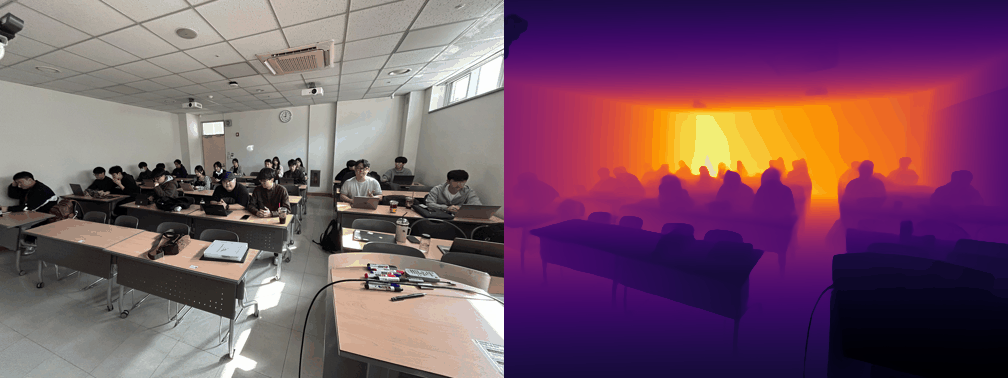

In [16]:
depths = prediction.depth  # (N, H, W)
d_min, d_max = depths.min(), depths.max()

depth_gif_frames = []
for i in range(len(raw_frames)):
    h, w = depths[i].shape
    orig = np.array(Image.fromarray(raw_frames[i]).resize((w, h)))

    d_norm = (depths[i] - d_min) / (d_max - d_min + 1e-8)
    d_color = (plt.cm.inferno(d_norm)[:, :, :3] * 255).astype(np.uint8)

    depth_gif_frames.append(np.concatenate([orig, d_color], axis=1))

depth_gif_path = os.path.join(OUTPUT_DIR, "depth_video.gif")
imageio.mimsave(depth_gif_path, depth_gif_frames, fps=SAMPLE_FPS, loop=0)
print(f"Depth GIF: {depth_gif_path} ({os.path.getsize(depth_gif_path)/1024/1024:.1f} MB, {len(depth_gif_frames)} frames)")

display(IPImage(filename=depth_gif_path))

## 4. 3D Point Cloud 구성

Depth map + Camera Intrinsics/Extrinsics를 이용해 각 프레임의 픽셀을 3D 공간으로 back-project한다.

In [25]:
def backproject_to_3d(depth, intrinsics, extrinsics, images_u8, conf, conf_percentile=10):
    """Depth map → 3D 포인트 클라우드 (with colors)."""
    N, H, W = depth.shape
    us, vs = np.meshgrid(np.arange(W), np.arange(H))
    pix = np.stack([us, vs, np.ones_like(us)], axis=-1).reshape(-1, 3)  # (H*W, 3)

    # Confidence threshold
    conf_thr = np.percentile(conf, conf_percentile)
    print(f"Confidence threshold ({conf_percentile}th pct): {conf_thr:.4f}")

    pts_all, col_all = [], []
    for i in range(N):
        d = depth[i]
        valid = np.isfinite(d) & (d > 0) & (conf[i] >= conf_thr)
        if not valid.any():
            continue

        d_flat = d.reshape(-1)
        vidx = np.flatnonzero(valid.reshape(-1))

        K_inv = np.linalg.inv(intrinsics[i])
        ext = np.eye(4)
        ext[:3, :4] = extrinsics[i][:3, :4]
        c2w = np.linalg.inv(ext)

        rays = K_inv @ pix[vidx].T  # (3, M)
        Xc = rays * d_flat[vidx][None, :]
        Xc_h = np.vstack([Xc, np.ones((1, Xc.shape[1]))])
        Xw = (c2w @ Xc_h)[:3].T.astype(np.float32)

        cols = images_u8[i].reshape(-1, 3)[vidx]
        pts_all.append(Xw)
        col_all.append(cols)

    pts = np.concatenate(pts_all, 0)
    cols = np.concatenate(col_all, 0)
    print(f"Total points: {pts.shape[0]:,}")
    return pts, cols

# processed_images 준비 (추론 결과에 포함된 전처리된 이미지)
if prediction.processed_images is not None:
    images_u8 = prediction.processed_images
else:
    # fallback: 원본 프레임을 depth 해상도로 리사이즈
    dh, dw = prediction.depth.shape[1:]
    images_u8 = np.array([np.array(Image.fromarray(f).resize((dw, dh))) for f in raw_frames])

pts, cols = backproject_to_3d(
    prediction.depth, prediction.intrinsics, prediction.extrinsics,
    images_u8, prediction.conf, conf_percentile=10,
)

Confidence threshold (10th pct): 2.5620
Total points: 171,460


In [26]:
# 다운샘플링
MAX_POINTS = 300000
if pts.shape[0] > MAX_POINTS:
    idx = np.random.choice(pts.shape[0], MAX_POINTS, replace=False)
    pts, cols = pts[idx], cols[idx]
    print(f"Downsampled to {MAX_POINTS:,} points")

# 정규화: 중앙 정렬 + 스케일링
center = np.median(pts, axis=0)
pts_norm = pts - center
scale = np.percentile(np.abs(pts_norm), 95)
if scale > 0:
    pts_norm /= scale

# glTF 좌표 변환 (Y-up, Z-backward)
w2c0 = np.eye(4)
w2c0[:3, :4] = prediction.extrinsics[0][:3, :4]
flip = np.eye(4)
flip[1, 1] = -1
flip[2, 2] = -1
A = flip @ w2c0

pts_aligned = trimesh.transform_points(pts, A)
center_a = np.median(pts_aligned, axis=0)
pts_aligned -= center_a
scale_a = np.percentile(np.abs(pts_aligned), 95)
if scale_a > 0:
    pts_aligned /= scale_a

colors_f = cols.astype(np.float32) / 255.0
print(f"Point cloud ready: {pts_aligned.shape[0]:,} points")

Point cloud ready: 171,460 points


## 5. 3D GIF — 360° 회전 포인트 클라우드 렌더링

matplotlib의 3D scatter plot으로 포인트 클라우드를 회전시키며 렌더링한다.

Rendering 36 frames...
  12/36
  24/36
  36/36
3D GIF: /home/jaeyoung/workspace/deep-learning/depth_anything/outputs/notebook_3d/scene_3d.gif (1.4 MB)


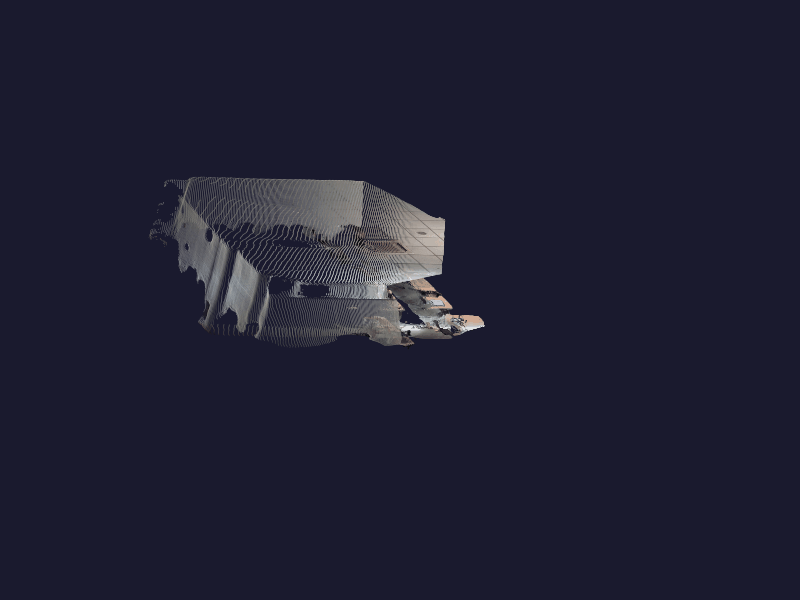

In [27]:
N_FRAMES = 36
GIF_3D_FPS = 12
BG_COLOR = "#1a1a2e"

print(f"Rendering {N_FRAMES} frames...")
render_frames = []
fig = plt.figure(figsize=(8, 6), dpi=100)

p = pts_aligned

for i in range(N_FRAMES):
    fig.clf()
    ax = fig.add_subplot(111, projection="3d")

    elev = 20 + 10 * np.sin(2 * np.pi * i / N_FRAMES)
    azim = 360 * i / N_FRAMES

    ax.scatter(p[:, 0], p[:, 2], p[:, 1], c=colors_f, s=0.3, alpha=0.8, edgecolors="none")
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)
    ax.set_axis_off()
    ax.set_facecolor(BG_COLOR)
    fig.patch.set_facecolor(BG_COLOR)
    fig.tight_layout(pad=0)
    fig.canvas.draw()

    buf = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
    render_frames.append(buf)

    if (i + 1) % 12 == 0:
        print(f"  {i + 1}/{N_FRAMES}")

plt.close(fig)

scene_3d_path = os.path.join(OUTPUT_DIR, "scene_3d.gif")
imageio.mimsave(scene_3d_path, render_frames, fps=GIF_3D_FPS, loop=0)
print(f"3D GIF: {scene_3d_path} ({os.path.getsize(scene_3d_path)/1024/1024:.1f} MB)")

display(IPImage(filename=scene_3d_path))

## 6. 결과 비교 & Cleanup

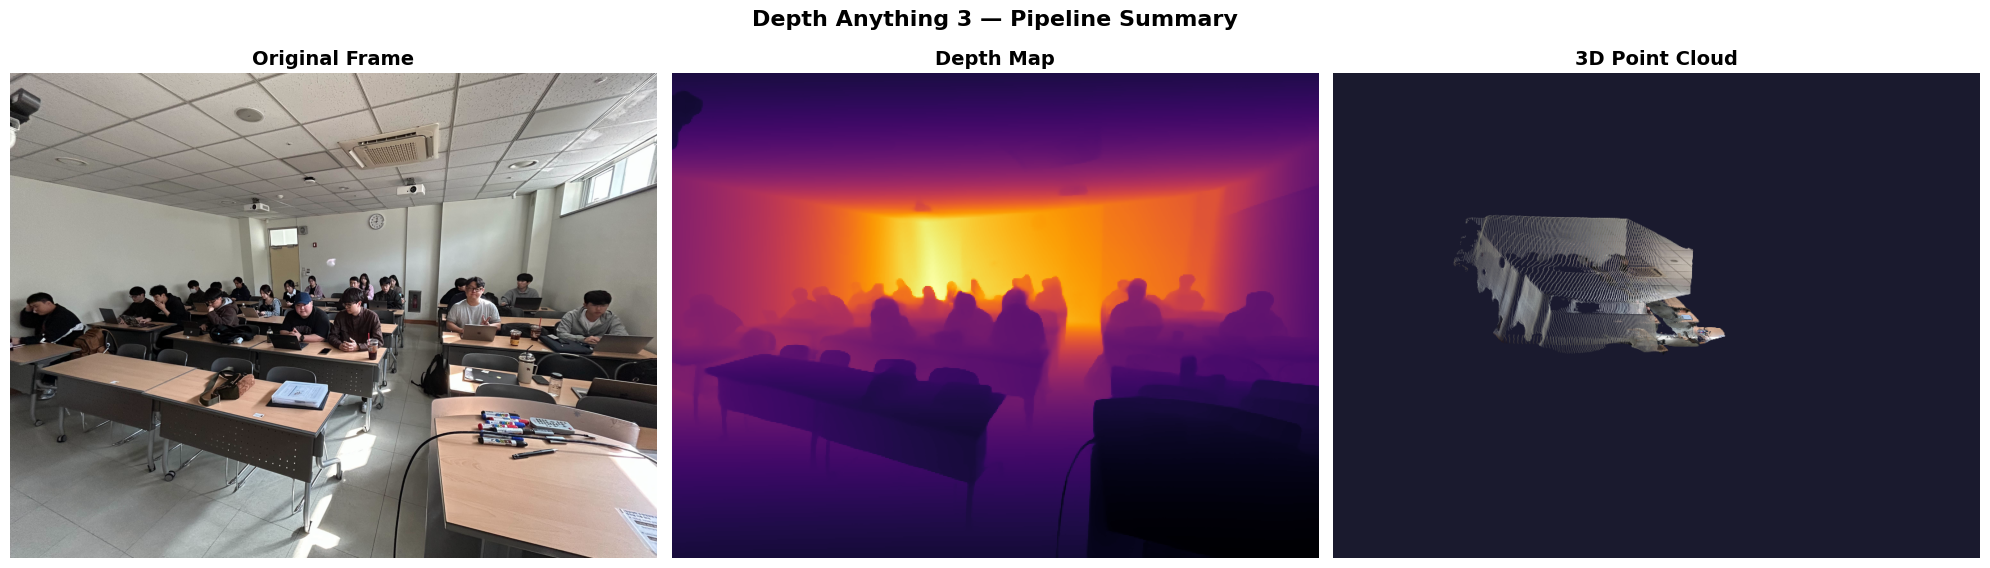


Generated files:
  Depth GIF: /home/jaeyoung/workspace/deep-learning/depth_anything/outputs/notebook_3d/depth_video.gif
  3D GIF:    /home/jaeyoung/workspace/deep-learning/depth_anything/outputs/notebook_3d/scene_3d.gif


In [10]:
# 대표 프레임으로 결과 요약
mid = len(depth_gif_frames) // 2
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(raw_frames[mid])
axes[0].set_title("Original Frame", fontsize=14, fontweight="bold")

d_norm = (depths[mid] - d_min) / (d_max - d_min + 1e-8)
axes[1].imshow(d_norm, cmap="inferno")
axes[1].set_title("Depth Map", fontsize=14, fontweight="bold")

axes[2].imshow(render_frames[0])
axes[2].set_title("3D Point Cloud", fontsize=14, fontweight="bold")

for ax in axes:
    ax.axis("off")
plt.suptitle("Depth Anything 3 — Pipeline Summary", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nGenerated files:")
print(f"  Depth GIF: {depth_gif_path}")
print(f"  3D GIF:    {scene_3d_path}")

In [11]:
import gc

shutil.rmtree(tmp_dir, ignore_errors=True)
del model, prediction, raw_frames, depth_gif_frames, render_frames, pts, cols, pts_aligned, colors_f
gc.collect()
torch.cuda.empty_cache()

allocated = torch.cuda.memory_allocated(0) / 1024**2
print(f"GPU memory allocated: {allocated:.0f} MB")
print("All cleaned up.")

GPU memory allocated: 9 MB
All cleaned up.
